In [2]:
import gymnasium as gym
import numpy as np
import math
import os
import configparser
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt
from sb3_contrib.common.maskable.utils import get_action_masks



In [3]:
from src.hpc_env import HPCenv
from src.validation import Validation
from src.baseline import PercentileBaseline
from src.utils import mask_fn, get_config_as_dict
from src.carbon_intensity import CarbonIntensity

In [4]:
# Use interactive widget backend if ipympl is available; otherwise fallback to inline
try:
    import ipympl  # noqa: F401
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception:
    get_ipython().run_line_magic('matplotlib', 'inline')
    print('ipympl not available; using inline Matplotlib backend. Install with `pip install ipympl` for widgets.')


ipympl not available; using inline Matplotlib backend. Install with `pip install ipympl` for widgets.


In [5]:

# Load config with explicit path and typed parsing
config = configparser.ConfigParser()
config_path = os.path.join(os.getcwd(), 'config_file', 'config.ini')
config.read(config_path)

['/Users/mikkeldahl/green-hpc-scheduler/config_file/config.ini']

## Model validation

In [5]:
val = Validation()
val.load_dir("results/CI_B16384_RC_LR-00000_ETA0.0_C-None_Lu")
processed_stats, raw_stats = val.run_baselines(n_eval_episodes=1, mode="validation")

run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
run time mean:  4551.618791289455
run time std:  8432.999235776877
Max Allocated Processors: 256 ;max node: 256 ;max procs: 256 ;max execution time: 157980
Executing baseline:  FCFS Baseline
Episode  0
Executing baseline:  10-percentile Baseline
Episode  0
cutoff:  -1.011053028793765
cutoff:  -1.011053028793765
cutoff:  -1.011053028793765
cutoff:  -1.011053028793765
cutoff:

In [6]:
processed_stats

{'FCFS Baseline': {'Validation Reward': 18.841868820294778,
  'Avg Wait': 6241.402740396379,
  'Max Wait': 533605.0,
  'Avg Response': 10793.021531685834,
  'Avg Slowdown': 177.4515107448421,
  'Episode Duration': 7837750.0,
  'Carbon Emissions': 28091754.682081796,
  'Weighted Carbon Emissions': -28091754.682081796,
  'System Utilization': 0.5823901774464929,
  'Action Analysis': {'Total Actions': 23851,
   'Schedule Action Percentage': 34.271099744245525,
   'Fixed Delay Percentage': 0.1383589786591757,
   'Wait Delay Percentage': 65.5905412770953,
   'Fixed Delays': {'300s': 33},
   'Wait for Jobs': {'1 jobs': 15644}}},
 '10-percentile Baseline': {'Validation Reward': -171.87773079709842,
  'Avg Wait': 8736924.74724737,
  'Max Wait': 14737105.0,
  'Avg Response': 8741476.36603866,
  'Avg Slowdown': 402867.4249347136,
  'Episode Duration': 21805354.0,
  'Carbon Emissions': 19482574.3391975,
  'Weighted Carbon Emissions': -19482574.3391975,
  'System Utilization': 0.209335221674514,
 

In [7]:
val.load_dir("results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu")
val.render_timeseries_plot(raw_stats['25-percentile Baseline']['action_traces'])

FileNotFoundError: Configuration file not found at '/Users/mikkeldahl/green-hpc-scheduler/results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu/config.json'. Please ensure it exists.

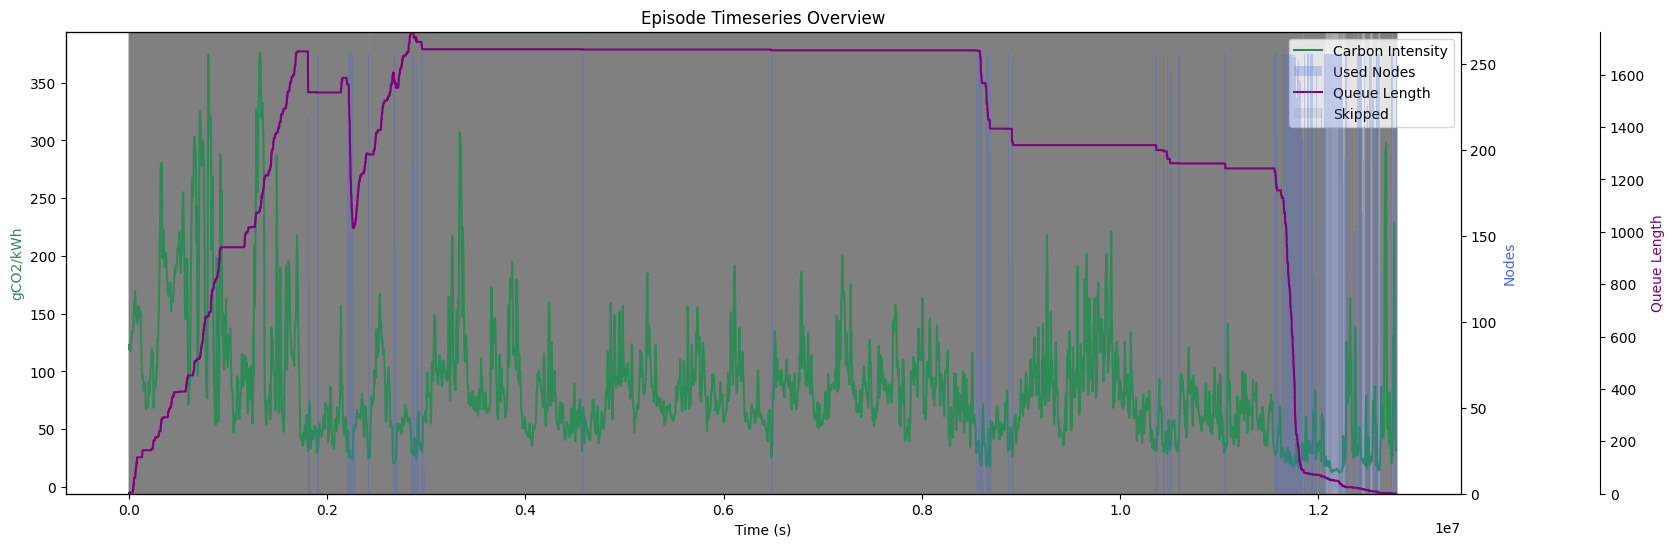

('renderings/timeseries.png', <Figure size 1800x600 with 3 Axes>)

In [ ]:
val.load_dir("results/CI_B4096_RC_LR-00001_ETA0.0_C-None_Lu")
val.render_timeseries_plot(raw_stats['10-percentile Baseline']['action_traces'])

In [ ]:
processed_stats

{'FCFS Baseline': {'Avg Wait': np.float64(4552.721755725191),
  'Max Wait': np.float64(4552.721755725191),
  'Avg Response': np.float64(8991.09351145038),
  'Avg Slowdown': np.float64(127.53263829568381),
  'Carbon Emissions': np.float64(9349788.624349324),
  'Weighted Carbon Emissions': np.float64(-9349788.624349324),
  'System Utilization': np.float64(0.45633334506960394),
  'Action Analysis': {'Total Actions': 10603,
   'Schedule Action Percentage': 24.70998773931906,
   'Fixed Delay Percentage': 24.38932377628973,
   'Wait Delay Percentage': 50.90068848439121,
   'Fixed Delays': {'300s': 2586},
   'Wait for Jobs': {'1 jobs': 5397}}},
 '10-percentile Baseline': {'Avg Wait': np.float64(6431648.060305344),
  'Max Wait': np.float64(6431648.060305344),
  'Avg Response': np.float64(6436086.432061069),
  'Avg Slowdown': np.float64(289532.42415359936),
  'Carbon Emissions': np.float64(6740089.32170967),
  'Weighted Carbon Emissions': np.float64(-6740089.32170967),
  'System Utilization': n

In [8]:
val = Validation()
val.load_dir("results/CI_B8192_RC_LR-00000_ETA200.0_C-None_Lu")
processed_stats, raw_stats  = val.validate_policy(n_eval_episodes=1, checkpoints=None, mode="validation")

In [10]:
processed_stats

{'seed_7_163840_steps.zip': {'Validation Reward': -1672940.7278476716,
  'Avg Wait': 205546.46268656716,
  'Max Wait': 8365596.0,
  'Avg Response': 210098.0814778566,
  'Avg Slowdown': 7097.971596481804,
  'Episode Duration': 8433951.0,
  'Carbon Emissions': 26352159.304153305,
  'Weighted Carbon Emissions': -26352159.304153305,
  'System Utilization': 0.5412206702743767,
  'Action Analysis': {'Total Actions': 27182,
   'Schedule Action Percentage': 30.071370760061807,
   'Fixed Delay Percentage': 33.018173791479654,
   'Wait Delay Percentage': 36.91045544845854,
   'Fixed Delays': {'1800s': 376,
    '3600s': 4264,
    '600s': 3435,
    '14400s': 309,
    '300s': 324,
    '7200s': 1,
    '43200s': 266},
   'Wait for Jobs': {'1 jobs': 9043, '2 jobs': 990}}},
 'seed_7_327680_steps.zip': {'Validation Reward': -672607.9862736063,
  'Avg Wait': 82575.3845118669,
  'Max Wait': 7925798.0,
  'Avg Response': 87127.00330315635,
  'Avg Slowdown': 2299.0258967366353,
  'Episode Duration': 8352485.

In [ ]:
val.render_timeseries_plot(raw_stats['seed_1_1500000_steps']['action_traces'])

KeyError: 'seed_1_1500000_steps'

### Best models in eta sweep

eta = 100,
seed_7_1310720_steps
eta = 50
seed_7_1802240_steps
eta = 200 
seed_7_655360_steps


In [ ]:
val = Validation()
val.load_dir("results/eta_sweep/CI_B8192_RC_LR-00000_ETA50.0_C-None_Lu")
results, raw_stats = val.validate_policy(n_eval_episodes=1, checkpoints=["seed_7_1802240_steps"], mode="test")

In [12]:
results

{'seed_7_1802240_steps': {'Validation Reward': -1166340.358850961,
  'Avg Wait': 165239.27125016786,
  'Max Wait': 19967285.0,
  'Avg Response': 169776.20146815272,
  'Avg Slowdown': 5333.514747771977,
  'Episode Duration': 21032265.0,
  'Carbon Emissions': 61796374.36460751,
  'Weighted Carbon Emissions': -61796374.36460751,
  'System Utilization': 0.5978229516501194,
  'Action Analysis': {'Total Actions': 69759,
   'Schedule Action Percentage': 32.0259751429923,
   'Fixed Delay Percentage': 48.929887183015815,
   'Wait Delay Percentage': 19.044137673991887,
   'Fixed Delays': {'600s': 1085,
    '300s': 687,
    '7200s': 11,
    '14400s': 4644,
    '1800s': 304,
    '3600s': 24657,
    '43200s': 2745},
   'Wait for Jobs': {'2 jobs': 4901, '1 jobs': 8384}}}}

In [20]:
val = Validation()
val.load_dir("results/eta_sweep/CI_B8192_RC_LR-00000_ETA50.0_C-None_Lu")
results, raw_stats = val.validate_policy(n_eval_episodes=1, checkpoints=["seed_7_1802240_steps"], mode="test")

FileNotFoundError: Configuration file not found at '/Users/mikkeldahl/green-hpc-scheduler/results/eta_sweep/CI_B8192_RC_LR-00000_ETA200.0_C-None_Lu/seed_7_1310720_steps/config.json'. Please ensure it exists.

In [14]:
results

{'seed_7_1802240_steps': {'Validation Reward': -1371988.8360002819,
  'Avg Wait': 101121.37415514077,
  'Max Wait': 19334874.0,
  'Avg Response': 105658.30437312565,
  'Avg Slowdown': 2503.470562594468,
  'Episode Duration': 20570115.0,
  'Carbon Emissions': 62195518.014480196,
  'Weighted Carbon Emissions': -62195518.014480196,
  'System Utilization': 0.6112542755442787,
  'Action Analysis': {'Total Actions': 70329,
   'Schedule Action Percentage': 31.766412148615792,
   'Fixed Delay Percentage': 47.79678368809453,
   'Wait Delay Percentage': 20.436804163289683,
   'Fixed Delays': {'600s': 539,
    '300s': 2195,
    '7200s': 13,
    '14400s': 3914,
    '1800s': 852,
    '3600s': 25772,
    '43200s': 330},
   'Wait for Jobs': {'2 jobs': 1169, '1 jobs': 13204}}}}

In [22]:
val = Validation()
val.load_dir("results/eta_sweep/CI_B8192_RC_LR-00000_ETA200.0_C-None_Lu")
results, raw_stats = val.validate_policy(n_eval_episodes=1, checkpoints=["seed_7_655360_steps"], mode="test")

In [23]:
results

{'seed_7_655360_steps': {'Validation Reward': -2029468.3635949432,
  'Avg Wait': 80331.43149366636,
  'Max Wait': 19357916.0,
  'Avg Response': 84868.36171165122,
  'Avg Slowdown': 1941.0599911336137,
  'Episode Duration': 20119259.0,
  'Carbon Emissions': 61960902.54161472,
  'Weighted Carbon Emissions': -61960902.54161472,
  'System Utilization': 0.6249519797020109,
  'Action Analysis': {'Total Actions': 69927,
   'Schedule Action Percentage': 31.949032562529496,
   'Fixed Delay Percentage': 49.9578131479972,
   'Wait Delay Percentage': 18.093154289473308,
   'Fixed Delays': {'600s': 791,
    '300s': 2149,
    '7200s': 13,
    '14400s': 11219,
    '1800s': 260,
    '43200s': 987,
    '3600s': 19515},
   'Wait for Jobs': {'2 jobs': 1546, '1 jobs': 11106}}}}